In [1]:
import numpy as np
import tensorflow as tf
import tensorflow_datasets as tfds
import tensorflow.keras.backend as K
from tensorflow.keras import layers, Model
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ⚡ Mixed precision — 2x faster on GPU
tf.keras.mixed_precision.set_global_policy('mixed_float16')

print(f'TF {tf.__version__} | GPU: {len(tf.config.list_physical_devices("GPU")) > 0}')
print(f'Precision: {tf.keras.mixed_precision.global_policy().name}')

2026-04-05 13:24:06.278152: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775395446.431356      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775395446.475121      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775395446.834534      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775395446.834580      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775395446.834584      55 computation_placer.cc:177] computation placer alr

TF 2.19.0 | GPU: True
Precision: mixed_float16


In [2]:
# ── Config ─────────────────────────────────────────────────────────────────────
IMG_SIZE = 256
BATCH    = 16
EPOCHS   = 20   # EarlyStopping will cut this to ~12-15
SEED     = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

In [3]:
# ── Data ───────────────────────────────────────────────────────────────────────
dataset, info = tfds.load('oxford_iiit_pet', with_info=True)
train_data = dataset['train']
test_data  = dataset['test']

def preprocess(data):
    image = tf.image.resize(data['image'], (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32) / 255.0
    mask  = tf.image.resize(data['segmentation_mask'], (IMG_SIZE, IMG_SIZE), method='nearest')
    mask  = tf.cast(mask, tf.float32)
    mask  = tf.where(mask > 1, 1.0, 0.0)
    return image, mask

def augment(image, mask):
    if tf.random.uniform(()) > 0.5:
        image = tf.image.flip_left_right(image)
        mask  = tf.image.flip_left_right(mask)
    if tf.random.uniform(()) > 0.5:
        image = tf.image.flip_up_down(image)
        mask  = tf.image.flip_up_down(mask)
    image = tf.image.random_brightness(image, 0.15)
    image = tf.image.random_contrast(image, 0.8, 1.2)
    image = tf.clip_by_value(image, 0.0, 1.0)
    return image, mask

train_ds = (
    train_data
    .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .map(augment,    num_parallel_calls=tf.data.AUTOTUNE)
    .shuffle(1000, seed=SEED)
    .batch(BATCH)
    .prefetch(tf.data.AUTOTUNE)
)
test_ds = (
    test_data
    .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH)
    .prefetch(tf.data.AUTOTUNE)
)
print('Data ready ✅')

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

I0000 00:00:1775395558.467653      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1775395558.473827      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.3ALI8E_4.0.0/oxford_iiit_pet-train.tfrecord*...…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.3ALI8E_4.0.0/oxford_iiit_pet-test.tfrecord*...:…

Dataset oxford_iiit_pet downloaded and prepared to /root/tensorflow_datasets/oxford_iiit_pet/4.0.0. Subsequent calls will reuse this data.
Data ready ✅


In [4]:
# ── Loss & Metrics ─────────────────────────────────────────────────────────────
def dice_coef(y_true, y_pred, smooth=1.0):
    y_true = K.flatten(tf.cast(y_true, tf.float32))
    y_pred = K.flatten(tf.cast(y_pred, tf.float32))
    inter  = K.sum(y_true * y_pred)
    return (2.0 * inter + smooth) / (K.sum(y_true) + K.sum(y_pred) + smooth)

def iou_coef(y_true, y_pred, smooth=1.0):
    y_true = K.flatten(tf.cast(y_true, tf.float32))
    y_pred = K.flatten(tf.cast(y_pred, tf.float32))
    inter  = K.sum(y_true * y_pred)
    union  = K.sum(y_true) + K.sum(y_pred) - inter
    return (inter + smooth) / (union + smooth)

def tversky_loss(y_true, y_pred, alpha=0.7, smooth=1.0):
    y_true = K.flatten(tf.cast(y_true, tf.float32))
    y_pred = K.flatten(tf.cast(y_pred, tf.float32))
    tp = K.sum(y_true * y_pred)
    fp = K.sum((1 - y_true) * y_pred)
    fn = K.sum(y_true * (1 - y_pred))
    return 1.0 - (tp + smooth) / (tp + alpha*fn + (1-alpha)*fp + smooth)

def combined_loss(y_true, y_pred):
    bce = tf.keras.losses.binary_crossentropy(
        tf.cast(y_true, tf.float32),
        tf.cast(y_pred, tf.float32)
    )
    return K.mean(bce) + tversky_loss(y_true, y_pred)

print('Losses ready ✅')

Losses ready ✅


In [5]:
# ── Building Blocks ────────────────────────────────────────────────────────────

# Plain conv block — used in baseline
def conv_block(x, filters):
    x = layers.Conv2D(filters, 3, padding='same', activation='relu')(x)
    x = layers.Conv2D(filters, 3, padding='same', activation='relu')(x)
    return x

# Residual block with BN — used in attention model
def res_block(x, filters):
    shortcut = layers.Conv2D(filters, 1, padding='same')(x)
    shortcut = layers.BatchNormalization()(shortcut)
    x = layers.Conv2D(filters, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(filters, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Add()([x, shortcut])
    x = layers.Activation('relu')(x)
    return x

# Attention Gate (Oktay et al. 2018) — gates skip connections spatially
def attention_gate(x, g, inter_ch):
    theta = layers.Conv2D(inter_ch, 1, padding='same')(x)
    phi   = layers.Conv2D(inter_ch, 1, padding='same')(g)
    if theta.shape[1] != phi.shape[1]:
        phi = layers.UpSampling2D()(phi)
    add = layers.Activation('relu')(layers.Add()([theta, phi]))
    psi = layers.Conv2D(1, 1, padding='same', activation='sigmoid')(add)
    return layers.multiply([x, psi])

In [6]:
# ── Model 1: Baseline U-Net (original, no attention, no BN) ───────────────────
def build_baseline(img_size=IMG_SIZE):
    inputs = layers.Input((img_size, img_size, 3))

    # Encoder
    c1 = conv_block(inputs, 32); p1 = layers.MaxPool2D()(c1)
    c2 = conv_block(p1, 64);     p2 = layers.MaxPool2D()(c2)

    # Bottleneck
    b = conv_block(p2, 128)
    b = layers.Dropout(0.3)(b)

    # Decoder
    u1 = layers.UpSampling2D()(b)
    u1 = layers.concatenate([u1, c2])
    c3 = conv_block(u1, 64)

    u2 = layers.UpSampling2D()(c3)
    u2 = layers.concatenate([u2, c1])
    c4 = conv_block(u2, 32)

    out = layers.Conv2D(1, 1, dtype='float32')(c4)
    out = layers.Activation('sigmoid', dtype='float32')(out)
    return Model(inputs, out, name='BaselineUNet')


baseline = build_baseline()
baseline.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss=combined_loss,
    metrics=['accuracy', dice_coef, iou_coef]
)
print(f'Baseline U-Net params: {baseline.count_params():,}')

Baseline U-Net params: 471,553


In [7]:
# ── Model 2: Residual Attention U-Net (upgraded) ──────────────────────────────
def build_attention_unet(img_size=IMG_SIZE):
    inputs = layers.Input((img_size, img_size, 3))

    # Encoder
    c1 = res_block(inputs, 32); p1 = layers.MaxPool2D()(c1)
    c2 = res_block(p1, 64);     p2 = layers.MaxPool2D()(c2)
    c3 = res_block(p2, 128);    p3 = layers.MaxPool2D()(c3)
    c4 = res_block(p3, 256);    p4 = layers.MaxPool2D()(c4)

    # Bottleneck
    b = res_block(p4, 512)
    b = layers.Dropout(0.4)(b)

    # Decoder with attention gates on every skip connection
    def decode(x, skip, f):
        x    = layers.UpSampling2D()(x)
        skip = attention_gate(skip, x, inter_ch=f // 2)
        x    = layers.concatenate([x, skip])
        return res_block(x, f)

    d4 = decode(b,  c4, 256)
    d3 = decode(d4, c3, 128)
    d2 = decode(d3, c2, 64)
    d1 = decode(d2, c1, 32)

    out = layers.Conv2D(1, 1, dtype='float32')(d1)
    out = layers.Activation('sigmoid', dtype='float32')(out)
    return Model(inputs, out, name='ResAttnUNet')


attn_model = build_attention_unet()
attn_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss=combined_loss,
    metrics=['accuracy', dice_coef, iou_coef]
)
print(f'Attention U-Net params: {attn_model.count_params():,}')

Attention U-Net params: 8,432,373


In [8]:
# ── Callbacks ──────────────────────────────────────────────────────────────────
def get_callbacks(name):
    return [
        tf.keras.callbacks.ModelCheckpoint(
            f'{name}_best.keras', monitor='val_iou_coef',
            mode='max', save_best_only=True, verbose=1
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=3,
            min_lr=1e-7, verbose=1
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor='val_iou_coef', mode='max',
            patience=6, restore_best_weights=True, verbose=1
        ),
    ]

In [9]:
# ── Train Baseline ─────────────────────────────────────────────────────────────
print('=' * 50)
print('  Training Baseline U-Net')
print('=' * 50)

baseline_history = baseline.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=test_ds,
    callbacks=get_callbacks('baseline'),
    verbose=1
)

  Training Baseline U-Net
Epoch 1/20


I0000 00:00:1775395631.908740     152 service.cc:152] XLA service 0x790cc8128d30 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775395631.908799     152 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1775395631.908805     152 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1775395632.787040     152 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-04-05 13:27:20.654229: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng0{} for conv %cudnn-conv-bw-input.10 = (f16[16,256,256,96]{3,2,1,0}, u8[0]{0}) custom-call(f16[16,256,256,32]{3,2,1,0} %bitcast.10064, f16[32,3,3,96]{3,2,1,0} %bitcast.9436), window={size=3x3 pad=1_1x1_1}, dim_labels=b01f_o01i->b01f, custom_call_target="__cudnn$convBackwardInput", metadata={op_type="Conv2DBackpropInput" op_name="gradient_tape/BaselineUNet_1/conv2d_8_1/convolution/Conv2DBackpropInput" sour

  1/230 ━━━━━━━━━━━━━━━━━━━━ 3:23:26 53s/step - accuracy: 0.6524 - dice_coef: 0.5761 - iou_coef: 0.4046 - loss: 1.1345

I0000 00:00:1775395679.257710     152 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


230/230 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.7007 - dice_coef: 0.7144 - iou_coef: 0.5592 - loss: 0.9078
Epoch 1: val_iou_coef improved from -inf to 0.66788, saving model to baseline_best.keras
230/230 ━━━━━━━━━━━━━━━━━━━━ 89s 155ms/step - accuracy: 0.7007 - dice_coef: 0.7145 - iou_coef: 0.5593 - loss: 0.9074 - val_accuracy: 0.7001 - val_dice_coef: 0.8003 - val_iou_coef: 0.6679 - val_loss: 0.7855 - learning_rate: 1.0000e-04
Epoch 2/20
230/230 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.7004 - dice_coef: 0.7706 - iou_coef: 0.6277 - loss: 0.7581
Epoch 2: val_iou_coef did not improve from 0.66788
230/230 ━━━━━━━━━━━━━━━━━━━━ 28s 111ms/step - accuracy: 0.7004 - dice_coef: 0.7706 - iou_coef: 0.6277 - loss: 0.7581 - val_accuracy: 0.7001 - val_dice_coef: 0.7910 - val_iou_coef: 0.6549 - val_loss: 0.7050 - learning_rate: 1.0000e-04
Epoch 3/20
230/230 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.7036 - dice_coef: 0.7824 - iou_coef: 0.6433 - loss: 0.7194
Epoch 3: val_iou_coef imp

In [10]:
# ── Train Attention U-Net ──────────────────────────────────────────────────────
print('=' * 50)
print('  Training Residual Attention U-Net')
print('=' * 50)

attn_history = attn_model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=test_ds,
    callbacks=get_callbacks('attn_unet'),
    verbose=1
)

  Training Residual Attention U-Net
Epoch 1/20


2026-04-05 13:39:09.884081: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng19{k2=0} for conv %cudnn-conv-bw-filter.60 = (f16[256,3,3,768]{3,2,1,0}, u8[0]{0}) custom-call(f16[16,32,32,768]{3,2,1,0} %bitcast.43499, f16[16,32,32,256]{3,2,1,0} %bitcast.43396), window={size=3x3 pad=1_1x1_1}, dim_labels=b01f_o01i->b01f, custom_call_target="__cudnn$convBackwardFilter", metadata={op_type="Conv2DBackpropFilter" op_name="gradient_tape/ResAttnUNet_1/conv2d_30_1/convolution/Conv2DBackpropFilter" source_file="/usr/local/lib/python3.12/dist-packages/tensorflow/python/framework/ops.py" source_line=1200}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kNone","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false} is taking a while...
2026-04-05 13:39:10.464021: E external/local_xla/xla/service/slow_operation_alarm.cc:140] The operation took 1.580132613s
Try

230/230 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step - accuracy: 0.7299 - dice_coef: 0.7451 - iou_coef: 0.6019 - loss: 0.8130
Epoch 1: val_iou_coef improved from -inf to 0.66451, saving model to attn_unet_best.keras
230/230 ━━━━━━━━━━━━━━━━━━━━ 160s 304ms/step - accuracy: 0.7301 - dice_coef: 0.7453 - iou_coef: 0.6022 - loss: 0.8123 - val_accuracy: 0.7001 - val_dice_coef: 0.7980 - val_iou_coef: 0.6645 - val_loss: 0.8278 - learning_rate: 1.0000e-04
Epoch 2/20
230/230 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step - accuracy: 0.8371 - dice_coef: 0.8479 - iou_coef: 0.7364 - loss: 0.5183
Epoch 2: val_iou_coef improved from 0.66451 to 0.72613, saving model to attn_unet_best.keras
230/230 ━━━━━━━━━━━━━━━━━━━━ 59s 247ms/step - accuracy: 0.8371 - dice_coef: 0.8480 - iou_coef: 0.7365 - loss: 0.5182 - val_accuracy: 0.8457 - val_dice_coef: 0.8410 - val_iou_coef: 0.7261 - val_loss: 0.5241 - learning_rate: 1.0000e-04
Epoch 3/20
230/230 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step - accuracy: 0.8623 - dice_coef: 0.8711 - iou_coef: 

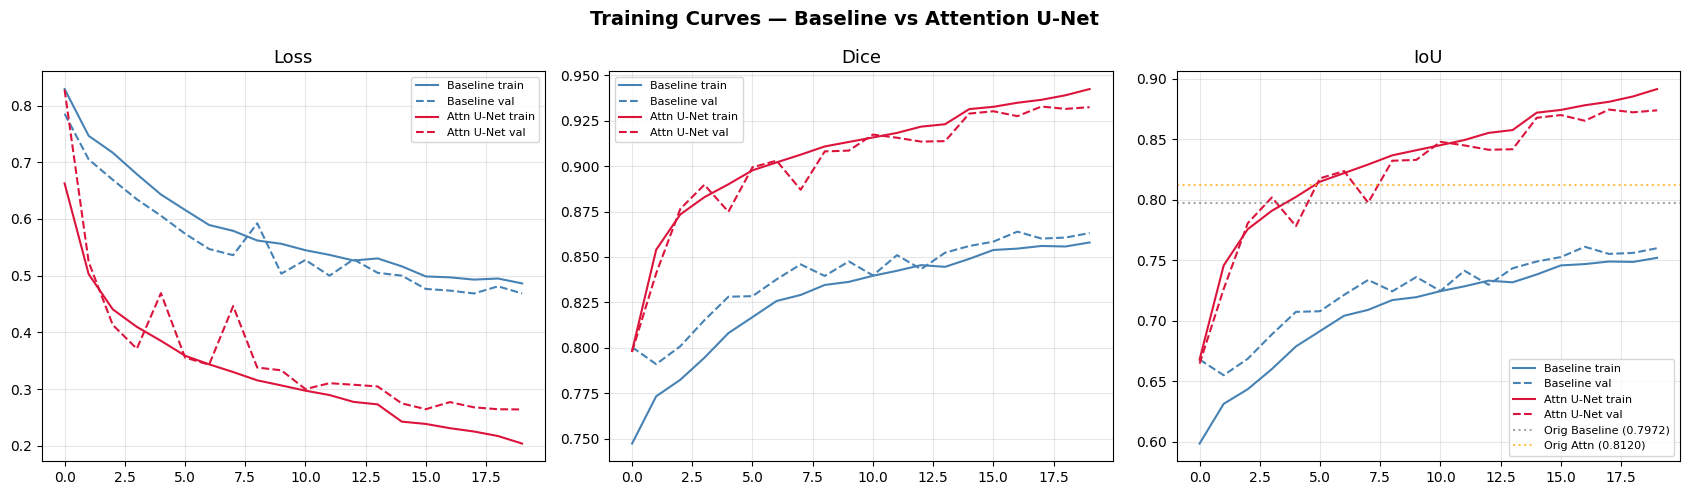

In [11]:
# ── Training Curves ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
pairs = [('loss', 'Loss'), ('dice_coef', 'Dice'), ('iou_coef', 'IoU')]

for ax, (key, title) in zip(axes, pairs):
    ax.plot(baseline_history.history[key],            color='steelblue', label='Baseline train')
    ax.plot(baseline_history.history[f'val_{key}'],   color='steelblue', linestyle='--', label='Baseline val')
    ax.plot(attn_history.history[key],                color='crimson',   label='Attn U-Net train')
    ax.plot(attn_history.history[f'val_{key}'],       color='crimson',   linestyle='--', label='Attn U-Net val')
    # Your old results as reference lines
    if key == 'iou_coef':
        ax.axhline(0.7972, color='gray',   linestyle=':', alpha=0.7, label='Orig Baseline (0.7972)')
        ax.axhline(0.8120, color='orange', linestyle=':', alpha=0.7, label='Orig Attn (0.8120)')
    ax.set_title(title, fontsize=13)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Training Curves — Baseline vs Attention U-Net', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [12]:
# ── Final Comparison Table ─────────────────────────────────────────────────────
ORIG_BASE = {'iou': 0.7972, 'dice': 0.8869, 'loss': 0.3837}
ORIG_ATTN = {'iou': 0.8120, 'dice': 0.8960, 'loss': 0.3631}

b_iou  = max(baseline_history.history['val_iou_coef'])
b_dice = max(baseline_history.history['val_dice_coef'])
b_loss = min(baseline_history.history['val_loss'])

a_iou  = max(attn_history.history['val_iou_coef'])
a_dice = max(attn_history.history['val_dice_coef'])
a_loss = min(attn_history.history['val_loss'])

print('\n' + '='*70)
print('                    FINAL COMPARISON')
print('='*70)
print(f"{'Metric':<8} | {'Orig Base':>10} | {'Orig Attn':>10} | {'New Base':>10} | {'New Attn':>10}")
print('-'*70)
print(f"{'IoU':<8} | {ORIG_BASE['iou']:>10.4f} | {ORIG_ATTN['iou']:>10.4f} | {b_iou:>10.4f} | {a_iou:>10.4f}")
print(f"{'Dice':<8} | {ORIG_BASE['dice']:>10.4f} | {ORIG_ATTN['dice']:>10.4f} | {b_dice:>10.4f} | {a_dice:>10.4f}")
print(f"{'Loss':<8} | {ORIG_BASE['loss']:>10.4f} | {ORIG_ATTN['loss']:>10.4f} | {b_loss:>10.4f} | {a_loss:>10.4f}")
print('='*70)
print(f"\nGain (New Attn vs Orig Attn):     IoU {a_iou - ORIG_ATTN['iou']:+.4f} | Dice {a_dice - ORIG_ATTN['dice']:+.4f}")
print(f"Gain (New Attn vs Orig Baseline): IoU {a_iou - ORIG_BASE['iou']:+.4f} | Dice {a_dice - ORIG_BASE['dice']:+.4f}")


                    FINAL COMPARISON
Metric   |  Orig Base |  Orig Attn |   New Base |   New Attn
----------------------------------------------------------------------
IoU      |     0.7972 |     0.8120 |     0.7610 |     0.8744
Dice     |     0.8869 |     0.8960 |     0.8640 |     0.9328
Loss     |     0.3837 |     0.3631 |     0.4687 |     0.2641

Gain (New Attn vs Orig Attn):     IoU +0.0624 | Dice +0.0368
Gain (New Attn vs Orig Baseline): IoU +0.0772 | Dice +0.0459


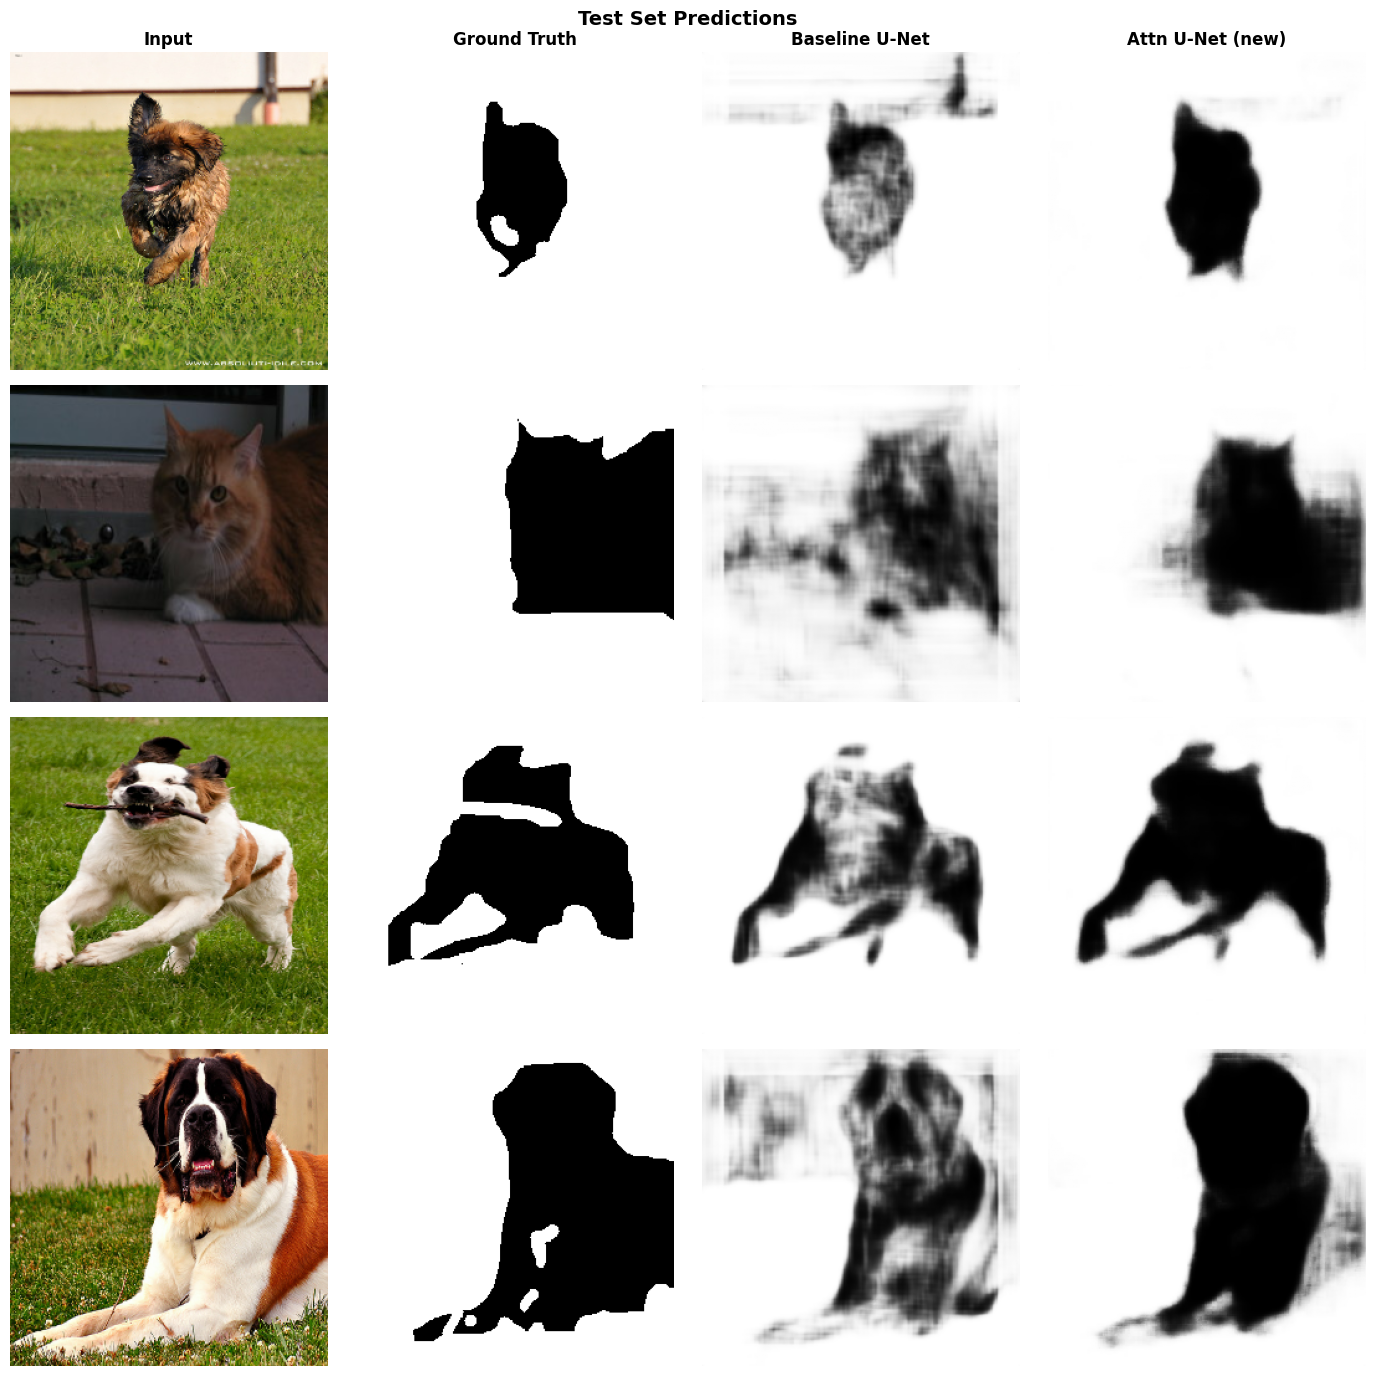

In [13]:
# ── Visual Comparison ──────────────────────────────────────────────────────────
for images, masks in test_ds.take(1):
    base_preds = baseline.predict(images, verbose=0)
    attn_preds = attn_model.predict(images, verbose=0)

    fig, axes = plt.subplots(4, 4, figsize=(14, 14))
    col_titles = ['Input', 'Ground Truth', 'Baseline U-Net', 'Attn U-Net (new)']
    for ax, t in zip(axes[0], col_titles):
        ax.set_title(t, fontsize=12, fontweight='bold')

    for i in range(4):
        axes[i, 0].imshow(images[i]);                               axes[i, 0].axis('off')
        axes[i, 1].imshow(masks[i].numpy().squeeze(), cmap='gray'); axes[i, 1].axis('off')
        axes[i, 2].imshow(base_preds[i].squeeze(),   cmap='gray'); axes[i, 2].axis('off')
        axes[i, 3].imshow(attn_preds[i].squeeze(),   cmap='gray'); axes[i, 3].axis('off')

    plt.suptitle('Test Set Predictions', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [14]:
# ── Save Models ────────────────────────────────────────────────────────────────
baseline.save('baseline_unet_final.keras')
attn_model.save('attn_unet_final.keras')
print('Models saved ✅')

Models saved ✅
